## Find the best ANN hyper-parameter first, and then run it 100 times

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import optuna

# # Load and preprocess the data
# df = pd.read_excel(r'../concrete data.xlsx', sheet_name='fc')
# df.dropna(inplace=True)

# Y = df.iloc[:, 0].values
# X = df.iloc[:, 1:].values

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

# Define features and target
X = df[['AGE', 'PC', 'PC_TYPE', 'FA','SS','SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values


x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).unsqueeze(1)
ytest = torch.tensor(ytest, dtype=torch.float32).unsqueeze(1)


class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def create_model(trial):
    layers = trial.suggest_int('layers', 1, 3)
    neurons = trial.suggest_int('neurons', 8, 64)
    learn_rate = trial.suggest_loguniform('learn_rate', 1e-4, 1e-1)
    
    model = RegressionModel(Xtrain.shape[1], layers, neurons)
    optimizer = optim.Adam(model.parameters(), lr=learn_rate)
    return model, optimizer

def train_model(model, optimizer, Xtrain, ytrain, epochs=100, batch_size=8):
    criterion = nn.MSELoss()
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

def objective(trial):
    model, optimizer = create_model(trial)
    train_model(model, optimizer, Xtrain, ytrain)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(Xtest)
    return mean_squared_error(ytest, y_pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_trial = study.best_trial
print('Best trial:', best_trial.params)

best_model, best_optimizer = create_model(best_trial)
train_model(best_model, best_optimizer, Xtrain, ytrain)

best_model.eval()
with torch.no_grad():
    ytrain_pred = best_model(Xtrain)
    ytest_pred = best_model(Xtest)

ytrain_pred = ytrain_pred.numpy()
ytest_pred = ytest_pred.numpy()

print(r2_score(ytrain.numpy(), ytrain_pred))
print(r2_score(ytest.numpy(), ytest_pred))

R2 = r2_score(ytest.numpy(), ytest_pred)
RMSE = mean_squared_error(ytest.numpy(), ytest_pred) ** 0.5
MAE = mean_absolute_error(ytest.numpy(), ytest_pred)
print('R-squared is {0}, RMSE is {1}, and MAE is {2}.'.format(R2, RMSE, MAE))


[I 2024-10-05 19:31:08,578] A new study created in memory with name: no-name-c8c6b11b-09a8-401f-9823-1db98197298d
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10-05 19:31:51,139] Trial 0 finished with value: 0.2847170829772949 and parameters: {'layers': 1, 'neurons': 54, 'learn_rate': 0.0006653381506610517}. Best is trial 0 with value: 0.2847170829772949.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10-05 19:32:54,117] Trial 1 finished with value: 0.9796304106712341 and parameters: {'layers': 2, 'neurons': 61, 'learn_rate': 0.08343285378369926}. Best is trial 0 with value: 0.2847170829772949.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See 

[I 2024-10-05 19:51:57,713] Trial 20 finished with value: 0.3240828812122345 and parameters: {'layers': 3, 'neurons': 41, 'learn_rate': 0.010877808068691092}. Best is trial 7 with value: 0.28073346614837646.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10-05 19:52:55,651] Trial 21 finished with value: 0.2676716446876526 and parameters: {'layers': 2, 'neurons': 52, 'learn_rate': 0.0007652946585818769}. Best is trial 21 with value: 0.2676716446876526.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10-05 19:53:53,231] Trial 22 finished with value: 0.29122164845466614 and parameters: {'layers': 2, 'neurons': 54, 'learn_rate': 0.0011079566867149755}. Best is trial 21 with value: 0.26767164468

suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10-05 20:12:34,196] Trial 41 finished with value: 0.29985547065734863 and parameters: {'layers': 2, 'neurons': 53, 'learn_rate': 0.0018654854291024147}. Best is trial 21 with value: 0.2676716446876526.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10-05 20:13:32,291] Trial 42 finished with value: 0.29209962487220764 and parameters: {'layers': 2, 'neurons': 56, 'learn_rate': 0.0013733914370278673}. Best is trial 21 with value: 0.2676716446876526.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
[I 2024-10

Best trial: {'layers': 2, 'neurons': 52, 'learn_rate': 0.0007652946585818769}
0.8641629188258512
0.7268086367065445
R-squared is 0.7268086367065445, RMSE is 0.517203227607867, and MAE is 0.3779451251029968.


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

# Define the ANN model
class ANNModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(ANNModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Create a folder to save models if it doesn't exist
model_dir = "ANN_best_trial"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# DataFrame to store results
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE'])

# Run the model 100 times with different parameters and splits
for run in range(1, 101):
    print(f'Run {run}')
    
    # Split the data randomly each time
    Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=run)

    # Convert inputs to torch tensors
    Xtrain = torch.FloatTensor(Xtrain)
    Xtest = torch.FloatTensor(Xtest)
    ytrain = torch.FloatTensor(ytrain).view(-1, 1)
    ytest = torch.FloatTensor(ytest).view(-1, 1)

    # Randomize ANN hyperparameters for each run
    layers = 2 # Number of layers between 2 and 5
    neurons = 52  # Number of neurons per layer
    learning_rate = 0.0007652946585818769  # Fixed learning rate

    # Create the ANN model
    ann_model = ANNModel(input_dim=Xtrain.shape[1], layers=layers, neurons=neurons)
    optimizer = optim.Adam(ann_model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Training the model
    epochs = 300
    for epoch in range(epochs):
        ann_model.train()
        optimizer.zero_grad()
        ytrain_pred = ann_model(Xtrain)
        loss = criterion(ytrain_pred, ytrain)
        loss.backward()
        optimizer.step()

    # Saving the model
    model_filename = os.path.join(model_dir, f'ann_model_run_{run}.pth')
    torch.save(ann_model.state_dict(), model_filename)

    # Evaluate the model
    ann_model.eval()
    with torch.no_grad():
        ytrain_pred = ann_model(Xtrain)
        ytest_pred = ann_model(Xtest)

    # Convert predictions and true values to numpy for metrics
    ytrain_pred = ytrain_pred.cpu().numpy()
    ytest_pred = ytest_pred.cpu().numpy()
    ytrain = ytrain.cpu().numpy()
    ytest = ytest.cpu().numpy()

    # Evaluate the model
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)

    # Append results to DataFrame using concat
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Run': run,
        'Test R2': test_r2,
        'Train R2': train_r2,
        'RMSE': rmse,
        'MAE': mae
    }])], ignore_index=True)

    # Print the results for this run
    print(f'Run {run}: Test R² = {test_r2}, Train R² = {train_r2}, RMSE = {rmse}, MAE = {mae}')

# Save the results to an Excel file
results_df.to_excel('ANN_best_trial_results.xlsx', index=False)

print("Results and models saved successfully.")


Run 1
Run 1: Test R² = 0.664322319935427, Train R² = 0.7385915215605694, RMSE = 0.5805751584919684, MAE = 0.4368523955345154
Run 2
Run 2: Test R² = 0.6406674291149956, Train R² = 0.7300458861521615, RMSE = 0.5913175901930323, MAE = 0.4444334805011749
Run 3
Run 3: Test R² = 0.654799941728093, Train R² = 0.7286150150062914, RMSE = 0.5861715993533578, MAE = 0.43920913338661194
Run 4
Run 4: Test R² = 0.6755654120300281, Train R² = 0.731920566151876, RMSE = 0.5488334193941558, MAE = 0.4074002206325531
Run 5
Run 5: Test R² = 0.6705775586733265, Train R² = 0.7257322486702813, RMSE = 0.5394951562991057, MAE = 0.4081556797027588
Run 6
Run 6: Test R² = 0.6570185857192057, Train R² = 0.7281144259876012, RMSE = 0.5693241072353117, MAE = 0.4236007034778595
Run 7
Run 7: Test R² = 0.6894476484313825, Train R² = 0.7257004818392769, RMSE = 0.5843576112495819, MAE = 0.4373953342437744
Run 8
Run 8: Test R² = 0.6952141964160024, Train R² = 0.7217977104991065, RMSE = 0.550210291584444, MAE = 0.419170796871

Run 66: Test R² = 0.6882200802790728, Train R² = 0.7328418419632907, RMSE = 0.5653131130925824, MAE = 0.41716447472572327
Run 67
Run 67: Test R² = 0.7059341599778421, Train R² = 0.7213865985056387, RMSE = 0.5327797071372031, MAE = 0.3982596695423126
Run 68
Run 68: Test R² = 0.6570466938666337, Train R² = 0.729988070454358, RMSE = 0.5819377952151307, MAE = 0.43046048283576965
Run 69
Run 69: Test R² = 0.6454988909641624, Train R² = 0.7423189138437956, RMSE = 0.5910497046690393, MAE = 0.43582379817962646
Run 70
Run 70: Test R² = 0.6754014592854906, Train R² = 0.7327241275365001, RMSE = 0.5928466349473187, MAE = 0.43744105100631714
Run 71
Run 71: Test R² = 0.6957734672903645, Train R² = 0.7474205174821329, RMSE = 0.5790633499378075, MAE = 0.4335589110851288
Run 72
Run 72: Test R² = 0.6706266390673923, Train R² = 0.7326584783049608, RMSE = 0.5715631072227293, MAE = 0.42807382345199585
Run 73
Run 73: Test R² = 0.6837705027622792, Train R² = 0.7245795025700914, RMSE = 0.5636514164310831, MAE 

## SHAR

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import joblib
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Convert Xtrain and Xtest back to DataFrames with proper column names
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']  # Define features
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

class ANNModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(ANNModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Randomize ANN hyperparameters for each run
layers = 2  # Number of layers between 2 and 5
neurons = 52  # Number of neurons per layer
learning_rate = 0.0007652946585818769  # Fixed learning rate

# Create the ANN model
ann_model = ANNModel(input_dim=Xtrain.shape[1], layers=layers, neurons=neurons)
optimizer = optim.Adam(ann_model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Training the model
epochs = 300
for epoch in range(epochs):
    ann_model.train()
    optimizer.zero_grad()
    ytrain_tensor = torch.FloatTensor(ytrain).view(-1, 1)  # Ensure ytrain is a column vector
    ytrain_pred = ann_model(torch.FloatTensor(Xtrain))
    loss = criterion(ytrain_pred, ytrain_tensor)
    loss.backward()
    optimizer.step()

# Perform SHAP analysis
explainer = shap.DeepExplainer(ann_model, torch.FloatTensor(Xtrain))  # Use DeepExplainer for PyTorch models
shap_values = explainer.shap_values(torch.FloatTensor(Xtest))  # Calculate SHAP values for the test data

# # Convert SHAP values to a numpy array for plotting
# shap_values_np = [shap_value.detach().numpy() for shap_value in shap_values]

# # Create summary plot
# shap.summary_plot(shap_values_np, Xtest_df, feature_names=features)





AttributeError: 'numpy.ndarray' object has no attribute 'detach'

<class 'numpy.ndarray'>


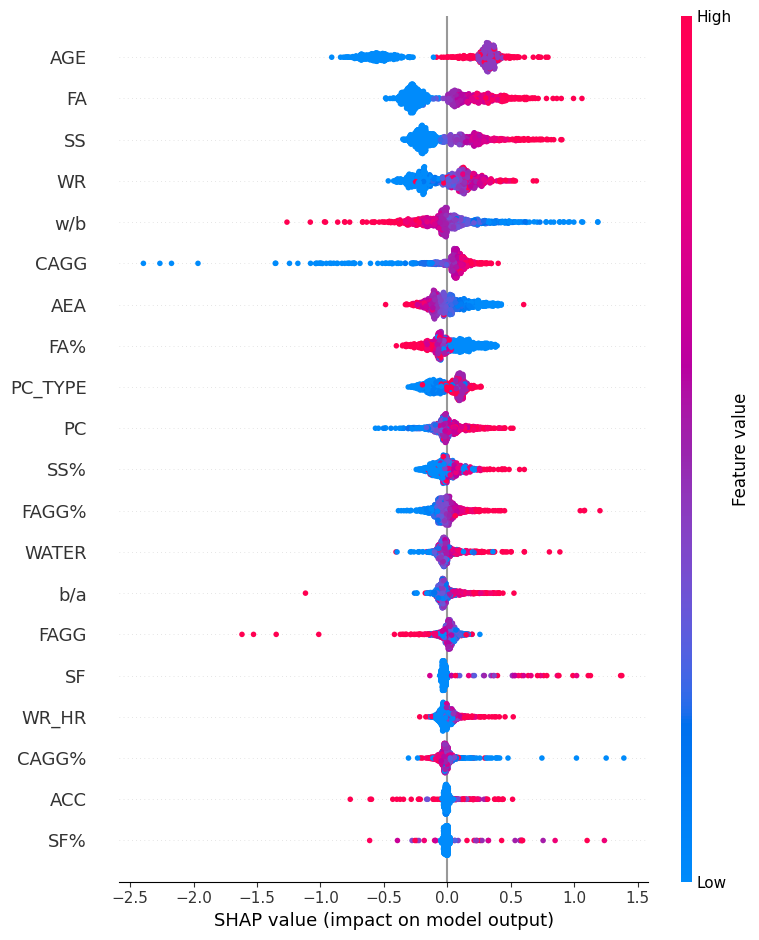

In [39]:
# Check the type of shap_values
print(type(shap_values))  # This will help you understand the structure of the output

# If shap_values is a list or tuple, extract the first element (for regression tasks)
if isinstance(shap_values, list) or isinstance(shap_values, tuple):
    shap_values_np = shap_values[0]  # Assuming the first element contains the relevant SHAP values
else:
    shap_values_np = shap_values  # If it's already a numpy array

# Create summary plot
shap.summary_plot(shap_values_np, Xtest_df, feature_names=features, show=False)

# Save the plot
plt.savefig('ANN_shap_summary_plot.png', bbox_inches='tight', dpi=300)  # You can change the filename and format as needed
# plt.close()  # Close the figure to free up memory

In [32]:

import matplotlib.pyplot as plt
import shap
import numpy as np

# Calculate mean absolute SHAP values
mean_abs_shap_values = np.abs(shap_values_np).mean(axis=0)

# Create a bar plot
plt.figure(figsize=(10, 6))
bar_plot = plt.barh(features, mean_abs_shap_values, color='skyblue')

# Add exact values to each bar
for bar in bar_plot:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f}', va='center')

plt.xlabel('Mean Absolute SHAP Value')
plt.title('Mean Absolute SHAP Values for Features')
plt.xlim(0, max(mean_abs_shap_values) * 1.1)  # Add some space to the right
plt.savefig('shap_mean_absolute_bar_plot.png', bbox_inches='tight', dpi=300)  # Save it
plt.close()  # Close the figure to free up memory

